# $\text{AR}(1)$ with Offset

$\text{AR}(1)$ with a constant offset is defined by,

$
\begin{equation}
X_t = \varphi X_{t-1} + \mu^* + \sigma \varepsilon_t
\end{equation}
\tag{1}
$

where, $\varepsilon \sim \text{Normal}(0,1)$

The stationarity requires $\lvert \varphi \rvert < 1$. The stationary mean and variance are given by,

$
\begin{align}
&\lim_{t \to \infty} \text{E}(X_t) = \frac{\mu^*}{1 - \varphi} \\
&\lim_{t \to \infty} \text{Var}(X_t) = \frac{\sigma^2}{1 - \varphi^2}
\end{align}
\tag{2}
$

It follows that $X_t$ has distribution,

$
\begin{align}
X_t \sim \text{Normal}\left(  \frac{\mu}{1 - \varphi} ,  \frac{\sigma^2}{1 - \varphi^2} \right)
\end{align}
\tag{3}
$

## Imports

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.plots import stack, fcurve, PlotType, curve
from lib.data import arima, stats
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
σ = 1.0
nsample = 1000

def cumu_mean_plot(φ, σ, μ, nsample):
    title = f"Convergence of Simulation Mean to $t\\rightarrow\infty$ Limit:  $\\phi=${φ}, $\\sigma=${σ}, $\\mu^*=${μ}"
    t, ar = arima.create_ar_offset_source(φ=[φ], σ=σ, μ=μ, npts=nsample)
    _, cumu_mean = stats.compute_cumu_mean(t, ar)
    _, ar_mean = arima.compute_ar1_offset_mean(φ=φ, μ=μ, npts=len(t))
    fcurve(data=cumu_mean, func=ar_mean, x=t, fx=t, title_offset=0.025, plot_axis_type=PlotType.XLOG, xlabel=r"$t$", ylabel=r"$\mu_t$",
           labels=["Simulation", r"$\mu_t\rightarrow \frac{\mu^*}{1 - \varphi}$"], title=title)
    
def cumu_sd_plot(φ, σ, μ, nsample):
    title = f"Convergence of Simulation Standard Deviation to $t\\rightarrow\infty$ Limit: $\\phi=${φ}, $\\sigma=${σ}, $\\mu^*=${μ}"
    t, ar = arima.create_ar_offset_source(φ=[φ], σ=σ, μ=μ, npts=nsample)
    _, cumu_sd = stats.compute_cumu_sd(t, ar)
    _, ar_sd = arima.compute_ar1_offset_sd(npts=len(t), φ=φ, σ=σ)
    fcurve(data=cumu_sd, func=ar_sd, x=t, fx=t, title_offset=0.025, plot_axis_type=PlotType.XLOG, xlabel=r"$t$", ylabel=r"$\sigma_t$",
           labels=["Simulation", r"$\sigma_t\rightarrow\sqrt{\frac{\sigma^2}{1-\varphi^2}}$"], title=title)
        
def comparison_plot_μ(μ_vals, ylim, title, *params):
    labels = [r"$μ^*=$" + f"{val}" for val in μ_vals]
    ylabels = r"$S_t$"
    source = lambda **kwargs : arima.create_ar_offset_source(**kwargs)
    t, scan = create_parameter_scan(source, *params)
    stack(scan, t, ylim=ylim, title=title, labels=labels, ylabels=ylabels, xlabel=r"$t$", figsize=(10, 6))
    
def comparison_plot_φ(φ_vals, ylim, title, *params):
    labels = [f"φ={val}" for val in φ_vals] 
    ylabels = r"$S_t$"
    source = lambda **kwargs : arima.create_ar_offset_source(**kwargs)
    t, scan = create_parameter_scan(source, *params)
    stack(scan, t, ylim=ylim, title=title, labels=labels, ylabels=ylabels, xlabel=r"$t$", figsize=(10, 6))


## Simulation $\varphi$ Scan

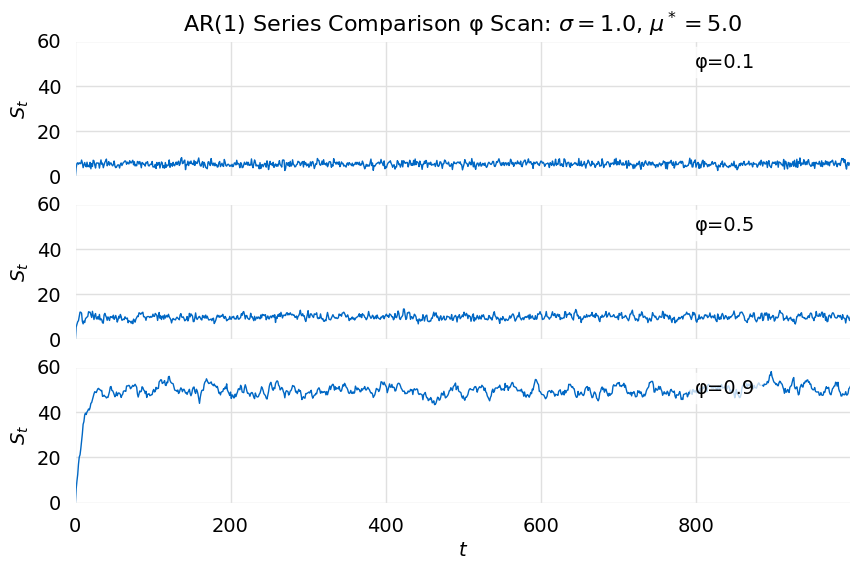

In [3]:
μ = 5.0
title = f"AR(1) Series Comparison φ Scan: $σ={{{σ}}}$, $μ^*={{{μ}}}$"
φ_vals = [0.1, 0.5, 0.9]
params = [{"φ": [φ], "σ": σ, "μ": μ, "npts": nsample} for φ in φ_vals]
comparison_plot_φ(φ_vals, [0.0, 60.0], title, *params)

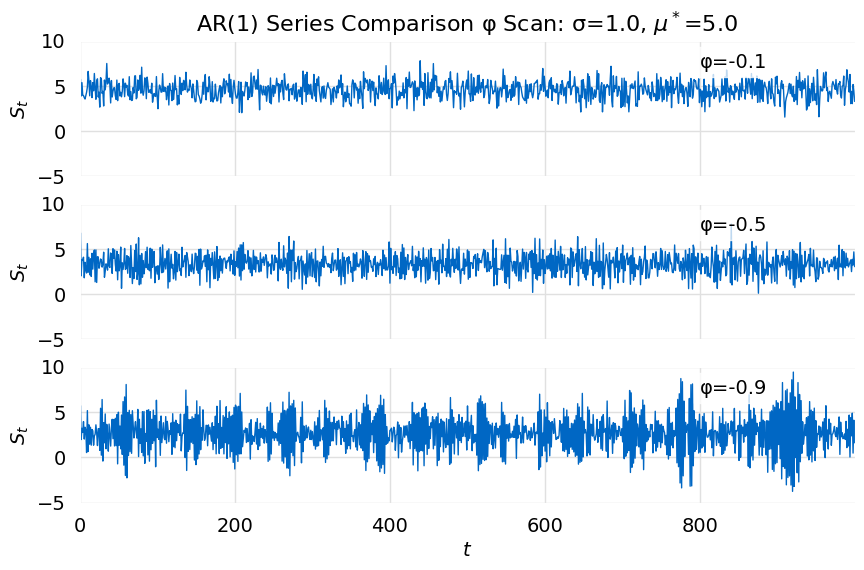

In [4]:
μ = 5.0
title = f"AR(1) Series Comparison φ Scan: σ={σ}, " + r"$μ^*$=" + f"{μ}"
φ_vals = [-0.1, -0.5, -0.9]
params = [{"φ": [φ], "σ": σ, "μ": μ, "npts": nsample} for φ in φ_vals]
comparison_plot_φ(φ_vals, [-5.0, 10.0], title, *params)

## Simulation $\mu^*$ Scan

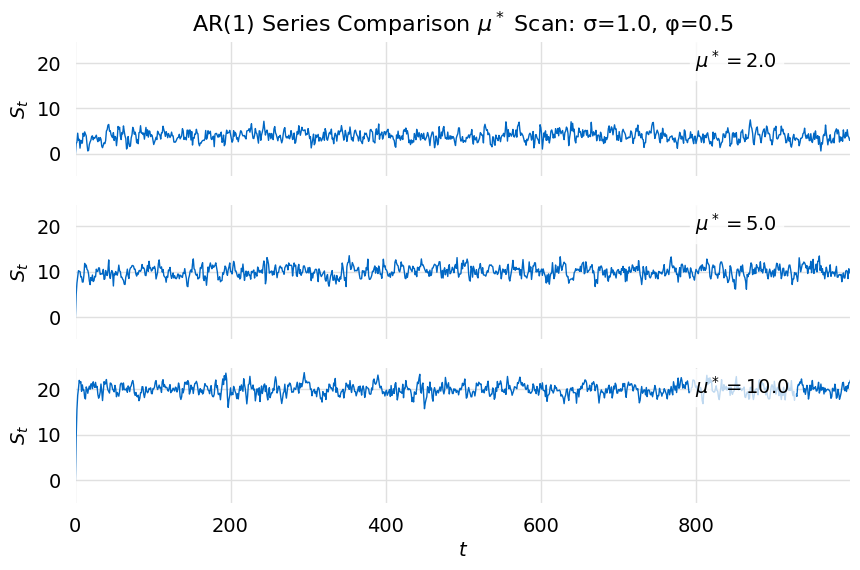

In [5]:
φ = 0.5
title = f"AR(1) Series Comparison " + r"$\mu^*$" + f" Scan: σ={σ}, φ={φ}"
μ_vals = [2.0, 5.0, 10.0]
params = [{"φ": [φ], "σ": σ, "μ": μ, "npts": nsample} for μ in μ_vals]
comparison_plot_μ(μ_vals, [-5.0, 25.0], title, *params)

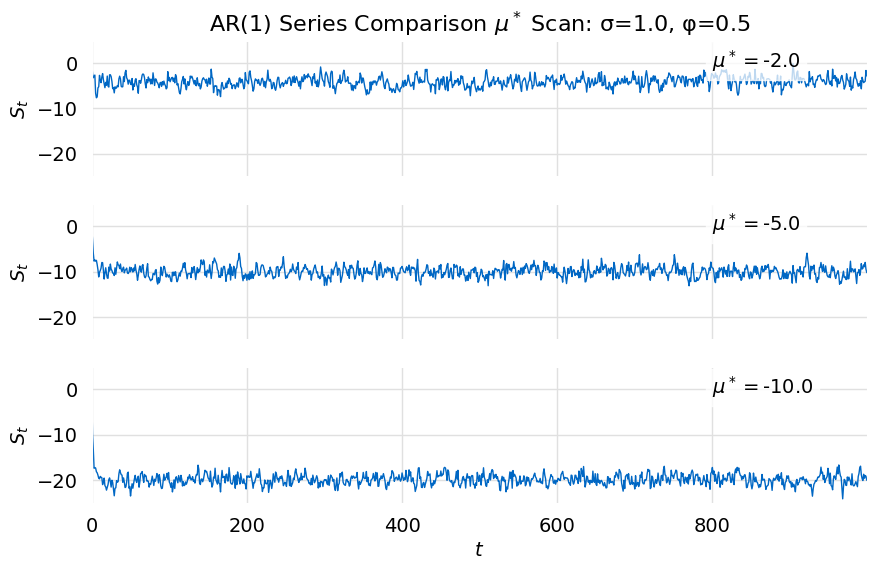

In [6]:
title = f"AR(1) Series Comparison " + r"$\mu^*$" + f" Scan: σ={σ}, φ={φ}"
μ_vals = [-2.0, -5.0, -10.0]
params = [{"φ": [φ], "σ": σ, "μ": μ, "npts": nsample} for μ in μ_vals]
comparison_plot_μ(μ_vals, [-25.0, 5.0], title, *params)

## Mean

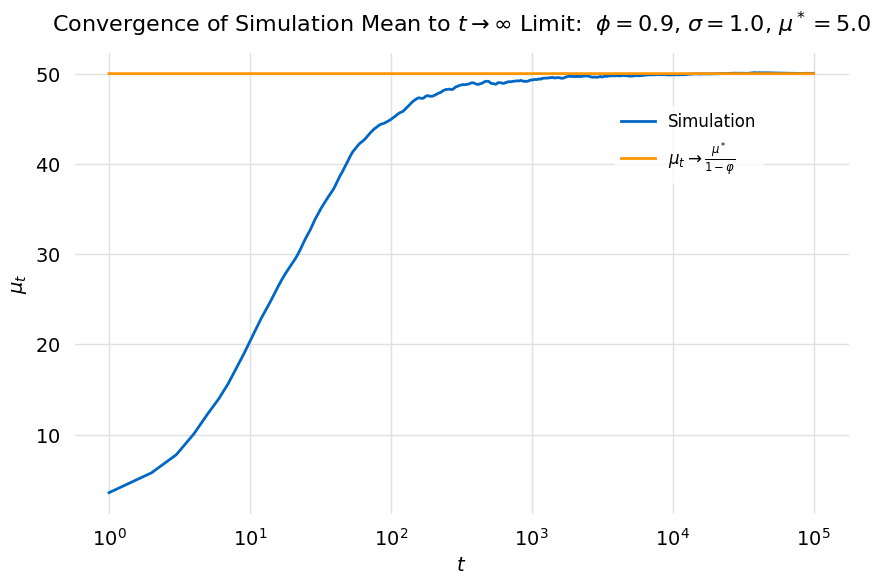

In [7]:
φ = 0.9
μ = 5.0
nsample = 100000
cumu_mean_plot(φ, σ, μ, nsample)

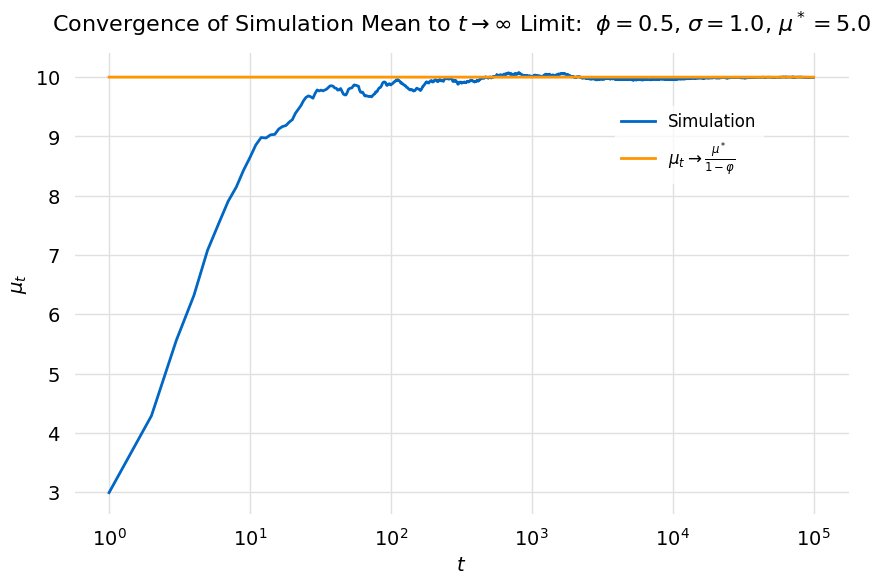

In [8]:
φ = 0.5
μ = 5.0
nsample = 100000
cumu_mean_plot(φ, σ, μ, nsample)

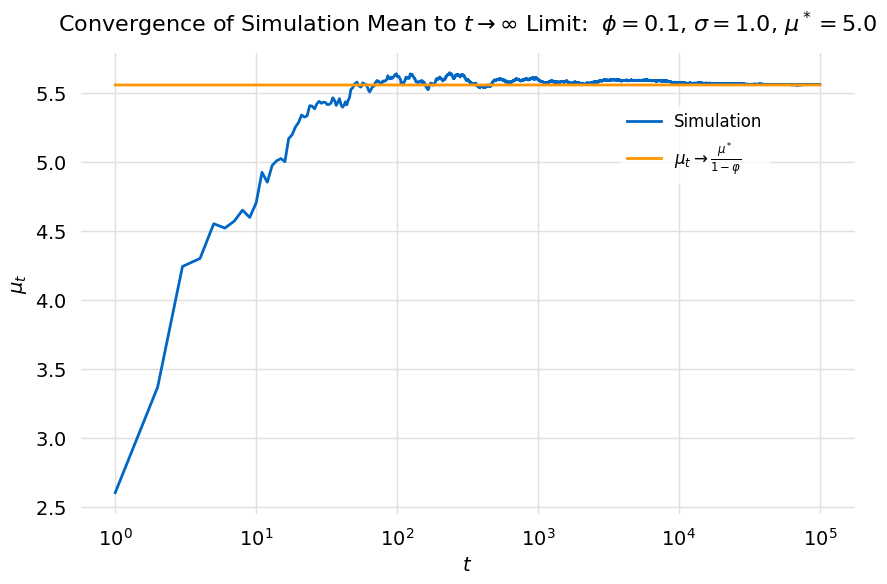

In [9]:
φ = 0.1
μ = 5.0
nsample = 100000
cumu_mean_plot(φ, σ, μ, nsample)

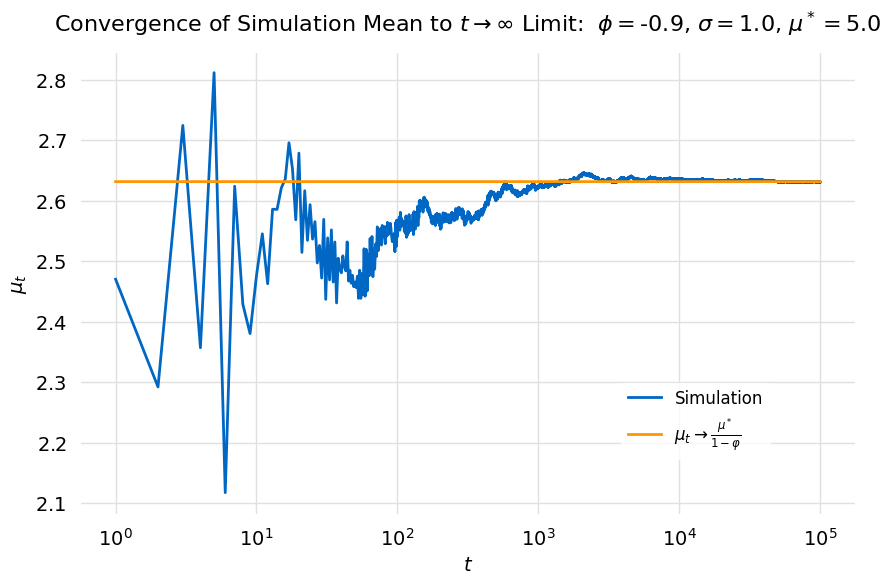

In [10]:
φ = -0.9
μ = 5.0
nsample = 100000
cumu_mean_plot(φ, σ, μ, nsample)

## Standard Deviation

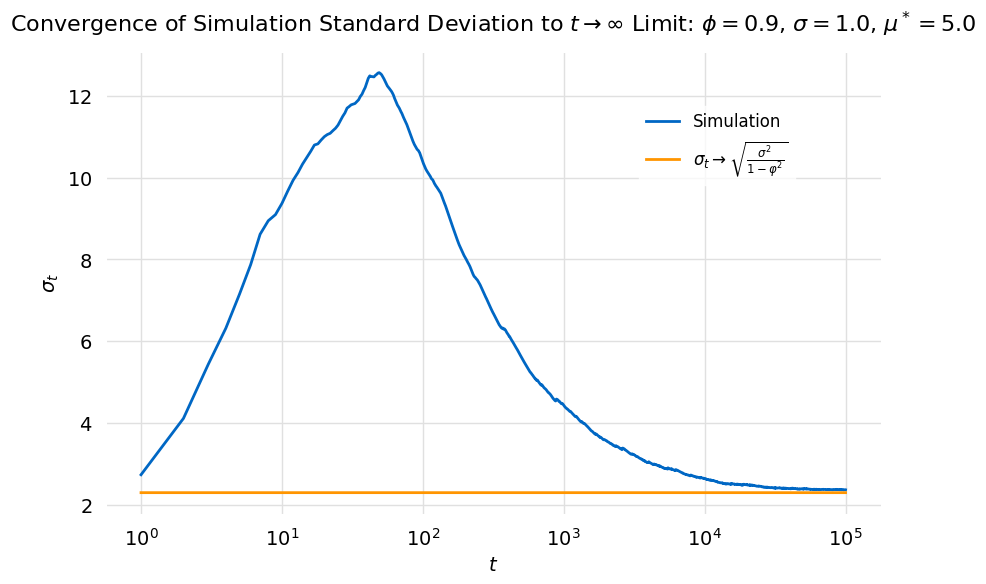

In [11]:
φ = 0.9
nsample = 100000
cumu_sd_plot(φ, σ, μ, nsample)

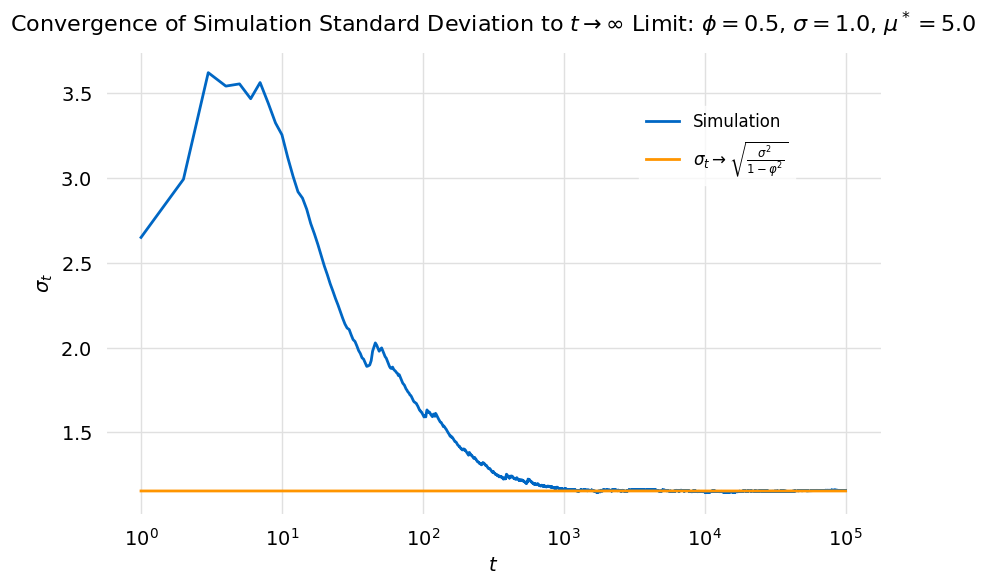

In [12]:
φ = 0.5
nsample = 100000
cumu_sd_plot(φ, σ, μ, nsample)

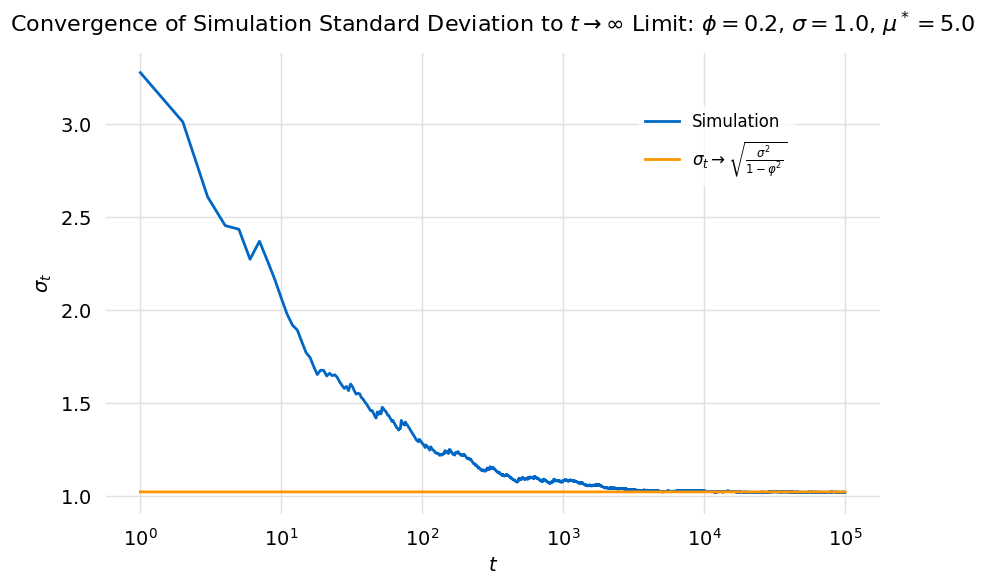

In [13]:
φ = 0.2
nsample = 100000
cumu_sd_plot(φ, σ, μ, nsample)

## Parameter Estimation

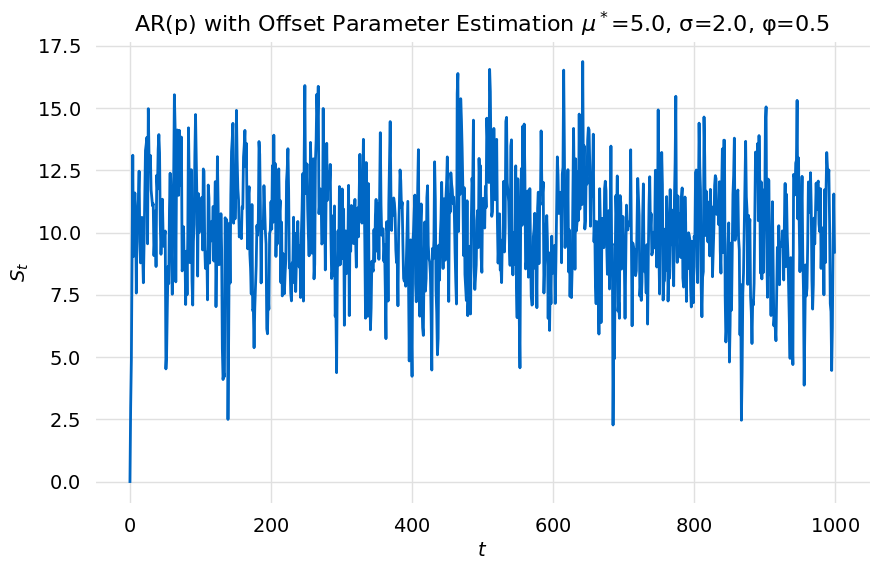

In [14]:
φ = 0.5
μ = 5.0
σ = 2.0
nsample = 1000
t, ar = arima.create_ar_offset_source(φ=[φ], σ=σ, μ=μ, npts=nsample)
title = f"AR(p) with Offset Parameter Estimation $\mu^*$={μ}, σ={σ}, φ={φ}"
curve(ar, t, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

In [15]:
result, result_model = arima.compute_ar_offset_estimate(ar, order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -2115.448
Date:                Sun, 23 Jul 2023   AIC                           4236.895
Time:                        11:16:06   BIC                           4251.619
Sample:                             0   HQIC                          4242.491
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.0804      0.125     80.488      0.000       9.835      10.326
ar.L1          0.4982      0.026     19.024      0.000       0.447       0.550
sigma2         4.0258      0.166     24.305      0.000       3.701       4.350
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):                 9.81
Prob(Q):                              0.80   Prob(JB):                         0.01
Heteroskedasticity (H):               0.98   Skew:                            -0.13
Prob(H) (two-sided):                  0.84   Kurtosis:                         3.41
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [16]:
result_model.dict

{'est_model': 'ARMA',
 'arma_est_type': 'AR_OFFSET',
 'order': 1,
 'const': {'Estimate': 10.08042733228179,
  'Error': 0.1252409607911396,
  'Estimate Label': '$\\hat{\\mu^*}$',
  'Error Label': '$\\sigma_{\\hat{\\mu^*}}$'},
 'sigma2': {'Estimate': 4.025800415369157,
  'Error': 0.16563690485515922,
  'Estimate Label': '$\\hat{\\sigma^2}$',
  'Error Label': '$\\sigma_{\\hat{\\sigma^2}}$'},
 'params': [{'Estimate': 0.49823928874176715,
   'Error': 0.026190338084014657,
   'Estimate Label': '$\\hat{\\phi_{0}}$',
   'Error Label': '$\\sigma_{$\\hat{\\phi_{0}}}$'}]}

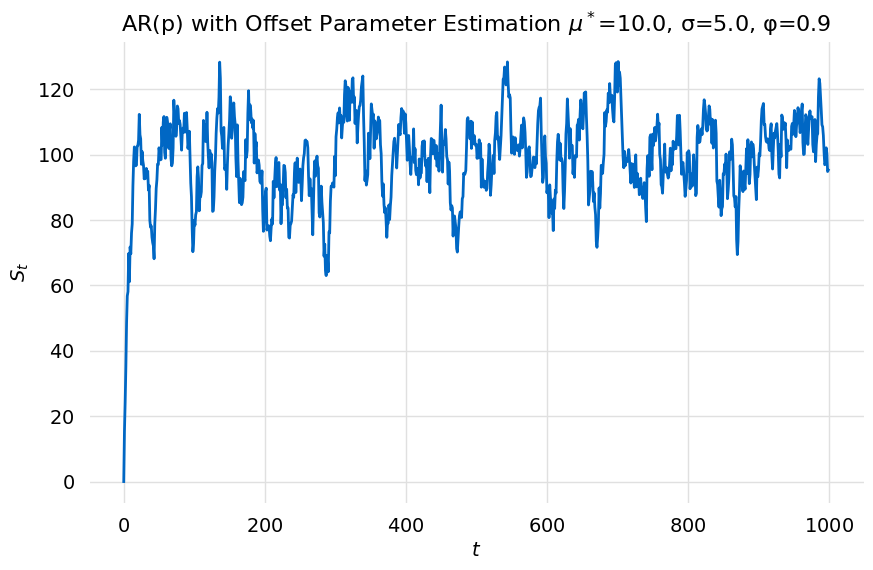

In [17]:
φ = 0.9
μ = 10.0
σ = 5.0
nsample = 1000
t, ar = arima.create_ar_offset_source(φ=[φ], σ=σ, μ=μ, npts=nsample)
title = f"AR(p) with Offset Parameter Estimation $\mu^*$={μ}, σ={σ}, φ={φ}"
curve(ar, t, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

In [18]:
result, result_model = arima.compute_ar_offset_estimate(ar, order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -3089.950
Date:                Sun, 23 Jul 2023   AIC                           6185.899
Time:                        11:16:06   BIC                           6200.623
Sample:                             0   HQIC                          6191.495
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         97.3116      2.613     37.243      0.000      92.190     102.433
ar.L1          0.9374      0.005    184.431      0.000       0.927       0.947
sigma2        28.2171      1.272     22.178      0.000      25.723      30.711
===================================================================================
Ljung-Box (L1) (Q):                   1.86   Jarque-Bera (JB):                91.63
Prob(Q):                              0.17   Prob(JB):                         0.00
Heteroskedasticity (H):               0.69   Skew:                            -0.29
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.36
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [19]:
result_model.dict

{'est_model': 'ARMA',
 'arma_est_type': 'AR_OFFSET',
 'order': 1,
 'const': {'Estimate': 97.31158856208576,
  'Error': 2.6128587453304775,
  'Estimate Label': '$\\hat{\\mu^*}$',
  'Error Label': '$\\sigma_{\\hat{\\mu^*}}$'},
 'sigma2': {'Estimate': 28.2171068778277,
  'Error': 1.2723091756485254,
  'Estimate Label': '$\\hat{\\sigma^2}$',
  'Error Label': '$\\sigma_{\\hat{\\sigma^2}}$'},
 'params': [{'Estimate': 0.937373294056945,
   'Error': 0.005082511457953473,
   'Estimate Label': '$\\hat{\\phi_{0}}$',
   'Error Label': '$\\sigma_{$\\hat{\\phi_{0}}}$'}]}

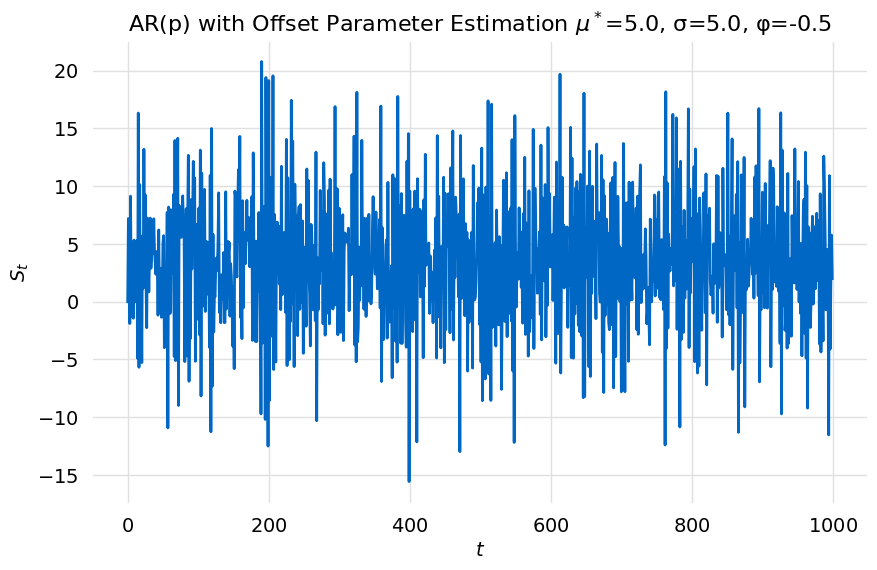

In [20]:
φ = -0.5
μ = 5.0
nsample = 1000
t, ar = arima.create_ar_offset_source(φ=[φ], σ=σ, μ=μ, npts=nsample)
title = f"AR(p) with Offset Parameter Estimation $\mu^*$={μ}, σ={σ}, φ={φ}"
curve(ar, t, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

In [21]:
result, result_model = arima.compute_ar_offset_estimate(ar, order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -2998.800
Date:                Sun, 23 Jul 2023   AIC                           6003.599
Time:                        11:16:06   BIC                           6018.322
Sample:                             0   HQIC                          6009.195
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.4706      0.102     34.173      0.000       3.272       3.670
ar.L1         -0.5118      0.028    -18.530      0.000      -0.566      -0.458
sigma2        23.5570      1.046     22.518      0.000      21.507      25.607
===================================================================================
Ljung-Box (L1) (Q):                   0.14   Jarque-Bera (JB):                 0.21
Prob(Q):                              0.70   Prob(JB):                         0.90
Heteroskedasticity (H):               0.95   Skew:                             0.03
Prob(H) (two-sided):                  0.67   Kurtosis:                         3.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [22]:
result_model.dict

{'est_model': 'ARMA',
 'arma_est_type': 'AR_OFFSET',
 'order': 1,
 'const': {'Estimate': 3.4705878797196634,
  'Error': 0.10155987773352347,
  'Estimate Label': '$\\hat{\\mu^*}$',
  'Error Label': '$\\sigma_{\\hat{\\mu^*}}$'},
 'sigma2': {'Estimate': 23.556997713956093,
  'Error': 1.0461462416017784,
  'Estimate Label': '$\\hat{\\sigma^2}$',
  'Error Label': '$\\sigma_{\\hat{\\sigma^2}}$'},
 'params': [{'Estimate': -0.5118015083205028,
   'Error': 0.02762073265916972,
   'Estimate Label': '$\\hat{\\phi_{0}}$',
   'Error Label': '$\\sigma_{$\\hat{\\phi_{0}}}$'}]}